# Machine Learning avancé — Jour 3 — Corrigé
## Classes rares, calibration et feature engineering

**Objectifs de la séance**

1. Distinguer score de ranking, probabilité calibrée et décision par seuil.
2. Comparer une baseline, `class_weight` et SMOTE sans fuite de données.
3. Calibrer un modèle avec des prédictions hors pli.
4. Construire et auditer des variables, puis démontrer leur utilité par ablation.

> Règle directrice : le test final reste fermé jusqu’à la toute fin. Toute opération qui apprend des données — imputation, encodage, sampling, sélection, calibration — vit dans le pipeline ou dans le train du pli.

In [1]:
# Exécuter une seule fois si nécessaire dans Colab
# %pip -q install scikit-learn==1.9.1 imbalanced-learn==0.14.2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, make_scorer,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             brier_score_loss, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
N_JOBS = 2  # Parallélisme borné ; la calibration interne reste séquentielle.
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option('display.max_columns', 50)

## 1. Jeu de données pédagogique

Nous simulons une campagne avec 8 % de positifs avant bruit de labels (la prévalence réalisée est proche de 9 %). Le jeu contient :
- des variables numériques avec asymétrie et valeurs manquantes ;
- des catégories de fréquences différentes, mais pas de très forte cardinalité ;
- une variable de récence synthétique, sans vraie chronologie des observations ;
- une colonne volontairement interdite : `duration_after_call`, connue **après** la décision d’appeler.

Les noms des six variables de `make_classification` sont pédagogiques : le générateur mélange les colonnes, donc le nom `noise` ne garantit pas une absence de signal. `job`, `channel` et `month` sont tirés indépendamment de la cible : leur encodage ne doit pas créer artificiellement du pouvoir prédictif.

In [2]:
X_num, y = make_classification(
    n_samples=5000, n_features=6, n_informative=4, n_redundant=1,
    weights=[0.92, 0.08], class_sep=0.9, flip_y=0.02, random_state=RANDOM_STATE
)

df = pd.DataFrame(X_num, columns=['age_proxy', 'income_signal', 'contact_history',
                                  'macro_context', 'campaign_pressure', 'noise'])
df['income_eur'] = np.exp(10.1 + 0.55 * df['income_signal']).clip(1000, 250000)
df['previous_contacts'] = np.maximum(0, np.round(2 + 2 * df['contact_history'])).astype(int)
df['days_since_contact'] = np.where(df['previous_contacts'].eq(0), 999,
                                    rng.integers(1, 365, len(df)))
df['job'] = rng.choice(['admin', 'technician', 'services', 'student', 'retired'],
                       size=len(df), p=[.30, .25, .22, .10, .13])
df['channel'] = rng.choice(['phone', 'mobile', 'web'], size=len(df), p=[.55, .35, .10])
df['month'] = rng.choice(['mar', 'apr', 'may', 'jun', 'jul'], size=len(df))
df.loc[rng.random(len(df)) < .08, 'income_eur'] = np.nan
# À exclure : information connue seulement une fois l'appel terminé
df['duration_after_call'] = np.maximum(0, 80 + 120*y + rng.normal(0, 35, len(df)))

X = df.drop(columns='duration_after_call')
print('Prévalence positive :', f'{y.mean():.1%}')
print('Dimensions :', X.shape)
X.head()

Prévalence positive : 9.2%
Dimensions : (5000, 12)


,age_proxy,income_signal,contact_history,macro_context,campaign_pressure,noise,income_eur,previous_contacts,days_since_contact,job,channel,month
0,-1.377439,-1.812706,0.348852,-0.626727,-0.081979,0.708866,8982.306261,3,33,admin,phone,jul
1,0.428340,0.246052,0.077125,1.111477,-0.662901,0.185497,27870.630094,2,282,services,mobile,jun
2,-3.844618,-1.914190,-0.274147,1.257350,2.255385,-0.305075,8494.681375,1,239,retired,phone,may
3,-1.160531,-0.235972,0.402646,-0.023627,-0.304588,0.487380,21380.089095,3,160,student,phone,mar
4,0.031518,-1.665150,0.862320,-1.848204,-1.735658,0.234923,9741.665569,4,158,admin,phone,mar


## 2. Split avant toute décision

On réserve 20 % des observations pour le test final, puis 25 % du développement pour la validation : **60 % train, 20 % validation, 20 % test**. Les splits sont stratifiés.

- **Train** : comparaison des modèles et ablations sur les mêmes cinq plis ; calibration interne sur des prédictions hors pli.
- **Validation** : diagnostics exploratoires et choix du seuil sous contrainte de capacité. Ses scores ne constituent plus une évaluation finale indépendante.
- **Test** : une seule évaluation en section 11, après avoir figé le modèle et la règle de décision.

Les observations sont ici synthétiques et supposées indépendantes. Un vrai identifiant client ou une vraie chronologie imposerait un split par groupes ou temporel, y compris dans la CV.

In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=RANDOM_STATE + 1
)
print(f'Train      : {len(X_train)} lignes — prévalence {y_train.mean():.2%}')
print(f'Validation : {len(X_valid)} lignes — prévalence {y_valid.mean():.2%}')
print(f'Test       : {len(X_test)} lignes — réservé à la section 11')
assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_dev.index).isdisjoint(X_test.index)

num_cols = ['age_proxy', 'income_signal', 'contact_history', 'macro_context',
            'campaign_pressure', 'noise', 'income_eur', 'previous_contacts', 'days_since_contact']
cat_cols = ['job', 'channel', 'month']

def make_preprocessor(numeric_columns, categorical_columns):
    return ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median', add_indicator=True)),
            ('scale', StandardScaler())
        ]), numeric_columns),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_columns)
    ])

preprocess = make_preprocessor(num_cols, cat_cols)

def make_logit(class_weight=None):
    return Pipeline([
        ('prep', clone(preprocess)),
        ('model', LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=RANDOM_STATE))
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 1)

Train      : 3000 lignes — prévalence 9.23%
Validation : 1000 lignes — prévalence 9.20%
Test       : 1000 lignes — réservé à la section 11


## 3. Baseline et déséquilibre

L’accuracy est souvent insuffisante avec une classe rare : prédire toujours « non » peut obtenir environ 91 % tout en ne détectant aucun positif. Nous comparons les modèles avec l’**Average Precision (AP)**, qui évalue le classement des positifs, et le **Brier score**, qui évalue la qualité probabiliste (plus petit est meilleur). Le Brier combine calibration et pouvoir de discrimination : ce n’est pas une mesure de calibration seule.

Le rappel et le volume d’alertes sont également mesurés au seuil **0,5**, identique pour tous les modèles. Le volume OOF cumule les prédictions des plis de validation : chacune des 3 000 lignes du train est comptée une fois. L’AP d’un score constant est la prévalence.

In [4]:
from sklearn.dummy import DummyClassifier

def alert_rate(y_true, y_pred):
    return np.mean(y_pred)

scoring = {
    'ap': 'average_precision', 'brier': 'neg_brier_score',
    'recall': 'recall', 'alert_rate': make_scorer(alert_rate)
}
cv_scores = {}
cv_format = {
    'AP moyenne': '{:.3f}', 'AP écart-type': '{:.3f}',
    'Brier moyen': '{:.5f}', 'Rappel à 0.5': '{:.3f}'
}

def summarize_cv(names):
    rows = []
    for name in names:
        scores = cv_scores[name]
        rows.append({
            'modèle': name, 'AP moyenne': scores['test_ap'].mean(),
            'AP écart-type': scores['test_ap'].std(),
            'Brier moyen': -scores['test_brier'].mean(),
            'Rappel à 0.5': scores['test_recall'].mean(),
            'Alertes OOF à 0.5': int(round(scores['test_alert_rate'].mean() * len(y_train)))
        })
    return pd.DataFrame(rows).sort_values('AP moyenne', ascending=False)

def evaluate_models(candidates):
    for name, model in candidates.items():
        cv_scores[name] = cross_validate(
            model, X_train, y_train, cv=cv, n_jobs=N_JOBS,
            scoring=scoring, error_score='raise'
        )
    return summarize_cv(candidates)

models = {
    'Dummy prior': Pipeline([('prep', clone(preprocess)), ('model', DummyClassifier(strategy='prior'))]),
    'Logistique': make_logit(),
    'Logistique pondérée': make_logit(class_weight='balanced')
}
results = evaluate_models(models)
results.style.format(cv_format)

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
1,Logistique,0.217,0.046,0.08054,0.000,8
2,Logistique pondérée,0.183,0.028,0.21663,0.646,1042
0,Dummy prior,0.092,0.001,0.08381,0.000,0


### Question

Pourquoi un modèle pondéré peut-il améliorer le rappel ou l’AP, tout en dégradant la calibration brute de ses probabilités ?

**Réponse.** La pondération augmente la pénalité des erreurs sur les positifs. Elle déplace la frontière de décision : au seuil 0,5, le modèle prédit souvent davantage de positifs et augmente le rappel, au prix de faux positifs. Le classement peut changer, mais **une hausse d’AP n’est pas garantie**.

La fonction de perte pondérée ne représente plus la prévalence naturelle. Dans un cas idéal, pour des poids $w_0,w_1$, la probabilité optimisée devient $q(x)=w_1p(x)/(w_1p(x)+w_0(1-p(x)))$, plutôt que le risque réel $p(x)$. Avec `balanced`, les deux classes ont le même poids total : les probabilités brutes surestiment souvent la classe rare. La calibration doit être apprise sur des observations non rééquilibrées, représentatives de la population visée.

## 4. SMOTE : uniquement dans le train de chaque pli

SMOTE fabrique des points synthétiques entre voisins minoritaires. Il faut l’appliquer **après le split** et **à l’intérieur de chaque pli d’entraînement** ; sinon des observations synthétiques trop proches peuvent contaminer la validation. Pour cela, on utilise `imblearn.pipeline.Pipeline`, et non la pipeline scikit-learn standard. Lors de `predict_proba`, le sampler n’est pas appliqué.

**Limite de cette démonstration :** après one-hot encoding, SMOTE interpole aussi les indicatrices de catégories et de valeurs manquantes, créant des valeurs fractionnaires. Le pipeline évite la fuite, mais ne garantit pas le réalisme des points synthétiques. Pour des données mixtes réelles, comparer à `SMOTENC`, avec catégories identifiées avant le one-hot final, et auditer les distances.

In [5]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_model = ImbPipeline([
    ('prep', clone(preprocess)),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

models['Logistique + SMOTE'] = smote_model
evaluate_models({'Logistique + SMOTE': smote_model})
summarize_cv(models).style.format(cv_format)

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
1,Logistique,0.217,0.046,0.08054,0.000,8
3,Logistique + SMOTE,0.184,0.028,0.21419,0.646,1019
2,Logistique pondérée,0.183,0.028,0.21663,0.646,1042
0,Dummy prior,0.092,0.001,0.08381,0.000,0


## 5. Ranking, calibration, décision

Ces trois objets sont différents :

- **Ranking** : l’ordre des clients, évalué par AP ou courbe précision-rappel.
- **Calibration** : une prédiction de 0,80 doit correspondre à environ 80 % de positifs dans un groupe comparable.
- **Décision** : une règle d’action transforme une probabilité en oui/non selon les coûts et la capacité opérationnelle.

Une amélioration sur l’un ne garantit pas une amélioration sur les deux autres. Les graphiques suivants utilisent uniquement la **validation** ; la logistique pondérée sert d’exemple pour visualiser le décalage des probabilités.

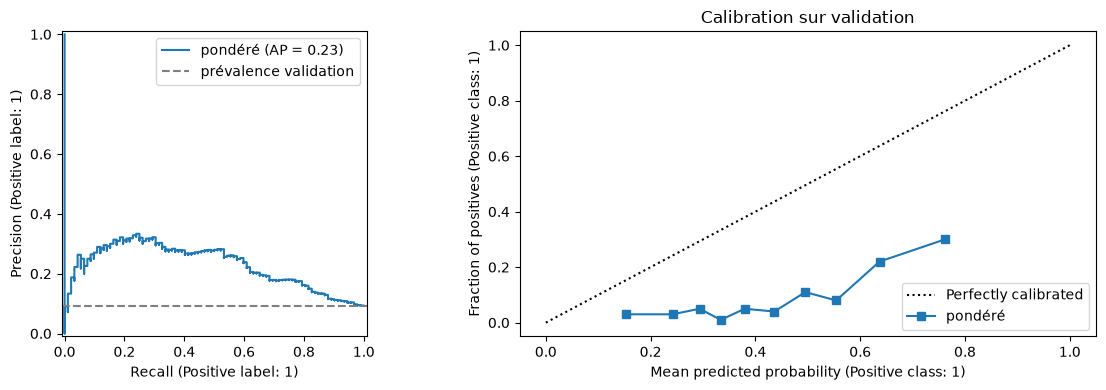

AP validation : 0.227
Brier validation : 0.202


In [6]:
base = make_logit(class_weight='balanced')
base.fit(X_train, y_train)
p_valid_raw = base.predict_proba(X_valid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PrecisionRecallDisplay.from_predictions(y_valid, p_valid_raw, ax=axes[0], name='pondéré')
axes[0].axhline(y_valid.mean(), ls='--', color='grey', label='prévalence validation')
axes[0].legend()
CalibrationDisplay.from_predictions(y_valid, p_valid_raw, n_bins=10, strategy='quantile', ax=axes[1], name='pondéré')
axes[1].set_title('Calibration sur validation')
plt.tight_layout()
plt.show()
print('AP validation :', round(average_precision_score(y_valid, p_valid_raw), 3))
print('Brier validation :', round(brier_score_loss(y_valid, p_valid_raw), 3))

## 6. Calibration sans fuite

Avec `ensemble=False`, `CalibratedClassifierCV` produit des scores hors pli sur le train pour apprendre la transformation de calibration, puis réentraîne le modèle de base sur tout le train. Le modèle de base qui produit le score d’une ligne n’a pas vu son label ; le calibrateur utilise ensuite ce score **et** son label comme exemple supervisé.

Cela ne rend pas l’évaluation du calibrateur sur ces mêmes lignes indépendante : on l’évalue ici sur la validation, et dans l’exercice 2 sur des **plis externes**. Le pipeline complet (prétraitement et éventuel sampling inclus) est placé à l’intérieur du calibrateur.

- `sigmoid` : plus contraint, souvent préférable avec peu de données ;
- `isotonic` : plus flexible, mais plus susceptible de surapprendre si l’échantillon de calibration est limité.

Une transformation sigmoïde strictement croissante conserve le classement du même modèle ; l’isotonique peut créer des ex æquo. Améliorer le Brier n’implique donc pas d’améliorer l’AP.

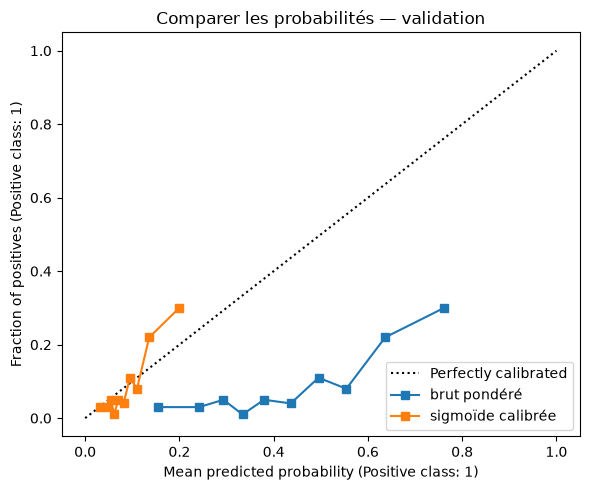

,modèle,AP validation,Brier validation
0,brut pondéré,0.227,0.202
1,calibré sigmoid,0.227,0.079


In [7]:
def make_calibrated(estimator, method):
    return CalibratedClassifierCV(
        estimator=clone(estimator), method=method, cv=inner_cv,
        ensemble=False, n_jobs=1
    )

calibrated = make_calibrated(make_logit(class_weight='balanced'), 'sigmoid')
calibrated.fit(X_train, y_train)
p_valid_cal = calibrated.predict_proba(X_valid)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(y_valid, p_valid_raw, n_bins=10, strategy='quantile', ax=ax, name='brut pondéré')
CalibrationDisplay.from_predictions(y_valid, p_valid_cal, n_bins=10, strategy='quantile', ax=ax, name='sigmoïde calibrée')
ax.set_title('Comparer les probabilités — validation')
plt.tight_layout()
plt.show()

pd.DataFrame({
    'modèle': ['brut pondéré', 'calibré sigmoid'],
    'AP validation': [average_precision_score(y_valid, p_valid_raw), average_precision_score(y_valid, p_valid_cal)],
    'Brier validation': [brier_score_loss(y_valid, p_valid_raw), brier_score_loss(y_valid, p_valid_cal)]
}).style.format({'AP validation': '{:.3f}', 'Brier validation': '{:.3f}'})

## 7. Choisir un seuil avec des coûts

Sous hypothèses simples — probabilités calibrées, coût des décisions correctes nul, coûts fixes, absence de contrainte de capacité — le seuil théorique est :

$$t^* = \frac{C_{FP}}{C_{FP}+C_{FN}} = \frac{1}{6} \approx 0{,}167.$$

Prédire positif coûte en espérance $C_{FP}(1-p)$, contre $C_{FN}p$ pour prédire négatif : on appelle si le premier coût est inférieur au second.

Nous fixons les coûts pédagogiques **FP = 1, FN = 5** et une capacité de **100 appels par lot de 1 000 clients**, avant d’inspecter le test. La règle appelle les clients au-dessus du seuil, classés par probabilité, dans la limite de 100. En cas d’ex æquo, l’ordre des lignes départage les clients. Le plafond restera appliqué sur test : un seuil seul ne garantit pas un volume fixe sur un nouveau lot.

Le seuil ci-dessous illustre cette règle sur la logistique pondérée calibrée. Il sera recalculé sur validation pour le modèle finalement retenu en section 11. **Le minimum sur validation est un résultat de réglage, pas une estimation indépendante du coût futur.**

Seuil théorique sans plafond : 0.167


,seuil,TN,FP,FN,TP,coût,alertes,précision,rappel
Sans plafond,0.128,783.0,125.0,43.0,49.0,340.0,174.0,0.282,0.533
Au plus 100 appels,0.161,849.0,59.0,64.0,28.0,379.0,87.0,0.322,0.304


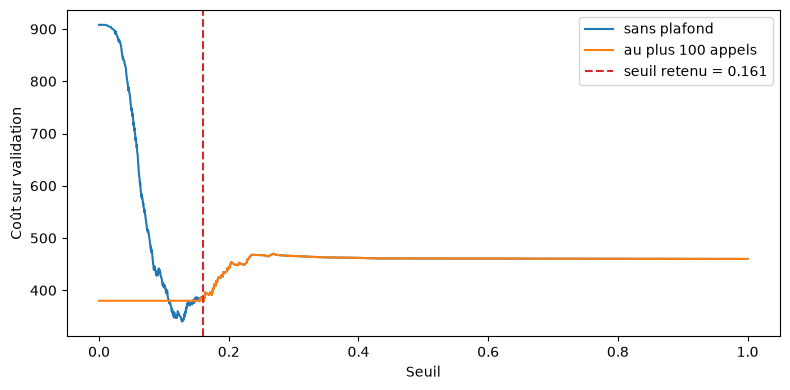

In [8]:
C_FP, C_FN = 1, 5
MAX_CALLS = 100
theoretical_threshold = C_FP / (C_FP + C_FN)

def decide(probabilities, threshold, max_calls=None):
    probabilities = np.asarray(probabilities)
    eligible = np.flatnonzero(probabilities >= threshold)
    if max_calls is not None:
        order = np.argsort(-probabilities[eligible], kind='stable')
        eligible = eligible[order[:max_calls]]
    pred = np.zeros(len(probabilities), dtype=int)
    pred[eligible] = 1
    return pred

def decision_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
        'coût': int(C_FP * fp + C_FN * fn), 'alertes': int(pred.sum()),
        'précision': tp / (tp + fp) if tp + fp else 0,
        'rappel': tp / (tp + fn) if tp + fn else 0
    }

def choose_threshold(y_true, probabilities, max_calls=None):
    # Tous les changements de décision, y compris appeler tout le monde / personne.
    thresholds = np.unique(np.r_[0.0, probabilities, np.nextafter(1.0, 2.0)])
    table = pd.DataFrame([
        {'seuil': t, **decision_metrics(y_true, decide(probabilities, t, max_calls))}
        for t in thresholds
    ])
    # À coût égal : moins d'appels, puis seuil le plus élevé.
    best = table.sort_values(['coût', 'alertes', 'seuil'], ascending=[True, True, False]).iloc[0]
    return table, best

unconstrained_table, unconstrained_best = choose_threshold(y_valid, p_valid_cal)
threshold_table, best = choose_threshold(y_valid, p_valid_cal, MAX_CALLS)
print('Seuil théorique sans plafond :', round(theoretical_threshold, 3))
display(pd.DataFrame([unconstrained_best, best], index=['Sans plafond', 'Au plus 100 appels']).round(3))
plt.figure(figsize=(8, 4))
plt.plot(unconstrained_table['seuil'], unconstrained_table['coût'], label='sans plafond')
plt.plot(threshold_table['seuil'], threshold_table['coût'], label='au plus 100 appels')
plt.axvline(best['seuil'], color='tab:red', ls='--', label=f"seuil retenu = {best['seuil']:.3f}")
plt.xlabel('Seuil'); plt.ylabel('Coût sur validation'); plt.legend(); plt.tight_layout()
plt.show()

## 8. Features : produire un signal défendable

Avant une transformation, documentez : **formule, unité, disponibilité temporelle, traitement des cas limites et hypothèse métier**.

Nous créons quatre variables dans un `FunctionTransformer` placé **au début du pipeline**. Les formules ne sont pas apprises ; l’imputation et la mise à l’échelle qui suivent le sont, uniquement dans le train du pli.

| Variable | Formule et unité | Cas limites et hypothèse |
|---|---|---|
| `had_previous_contact` | $1[days \ne 999]$, indicateur 0/1 | Date absente ou négative : manquant. Distingue absence d’historique et récence. |
| `days_since_contact_clean` | Jours, avec `999` remplacé par manquant | Valeur négative : manquant ; imputation médiane apprise dans le pli. `999` n’est pas une durée. |
| `log_income` | $\log(1+\max(revenu,0))$, revenu exprimé en euros | Zéro accepté, revenu manquant conservé, négatif ramené à zéro (convention pédagogique à auditer). Effet supposé décroissant du revenu. |
| `contacts_per_known_day` | Contacts / (1 + jours nettoyés), indice en contacts/jour | Dénominateur strictement positif ; 365 jours si récence absente, convention fixe. C’est un indice de récence, pas une fréquence d’appels observée. |

**Disponibilité :** revenu et historique supposés connus avant l’appel. Dans la famille « revenu », le log remplace `income_eur`. Dans la famille « contacts », les trois variables de récence remplacent `days_since_contact` ; `previous_contacts` reste disponible. La variable `income_signal`, déjà présente, rend le log potentiellement redondant.

La feature interdite `duration_after_call` reste exclue : elle est inconnue avant l’appel.

In [9]:
def add_features(frame, interaction=False):
    out = frame.copy()
    days = out['days_since_contact']
    out['had_previous_contact'] = days.ne(999).astype(float).where(days.notna() & days.ge(0))
    out['days_since_contact_clean'] = days.where(days.ne(999) & days.ge(0))
    out['log_income'] = np.log1p(out['income_eur'].clip(lower=0))
    out['contacts_per_known_day'] = out['previous_contacts'] / (1 + out['days_since_contact_clean'].fillna(365))
    if interaction:
        out['income_x_contact_rate'] = out['log_income'] * out['contacts_per_known_day']
    return out

def make_feature_model(use_income=True, use_contacts=True, interaction=False):
    selected_num = num_cols.copy()
    if use_income:
        selected_num.remove('income_eur')
        selected_num.append('log_income')
    if use_contacts:
        selected_num.remove('days_since_contact')
        selected_num += ['had_previous_contact', 'days_since_contact_clean', 'contacts_per_known_day']
    if interaction:
        selected_num.append('income_x_contact_rate')
    return Pipeline([
        ('features', FunctionTransformer(add_features, kw_args={'interaction': interaction}, validate=False)),
        ('prep', make_preprocessor(selected_num, cat_cols)),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])

feature_models = {
    'Features revenu': make_feature_model(use_contacts=False),
    'Features contacts': make_feature_model(use_income=False),
    'Features complètes': make_feature_model()
}
models.update(feature_models)
evaluate_models(feature_models).style.format(cv_format)

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
1,Features contacts,0.214,0.045,0.08067,0.000,9
0,Features revenu,0.213,0.042,0.08046,0.000,5
2,Features complètes,0.211,0.043,0.08058,0.000,5


## 9. Ablation et importance par permutation

Une feature n’est pas validée parce qu’elle paraît intuitive. On compare le même protocole **avec et sans une famille de variables**, à modèle, hyperparamètres et plis identiques. Les deltas ci-dessous sont appariés pli par pli à la baseline sans feature engineering. Une différence faible ou instable ne suffit pas à démontrer un gain ; l’écart-type sur cinq plis n’est pas un intervalle de confiance.

L’importance par permutation est calculée ensuite **sur validation**, après apprentissage sur train. On permute les colonnes brutes à l’entrée du pipeline : leurs variables dérivées sont donc recalculées ensemble. Cela mesure l’effet d’une source et de ses dérivées, pas celui d’une feature dérivée isolée. Les corrélations entre sources peuvent masquer ou partager l’importance ; aucune interprétation causale n’en découle.

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
0,Logistique,0.217,0.046,0.08054,0.000,8
2,Features contacts,0.214,0.045,0.08067,0.000,9
1,Features revenu,0.213,0.042,0.08046,0.000,5
3,Features complètes,0.211,0.043,0.08058,0.000,5


,famille,Δ AP moyen,écart-type des Δ,plis en progrès / 5
0,Features revenu,-0.0037,0.0063,2
1,Features contacts,-0.0028,0.0027,1
2,Features complètes,-0.0063,0.0061,1


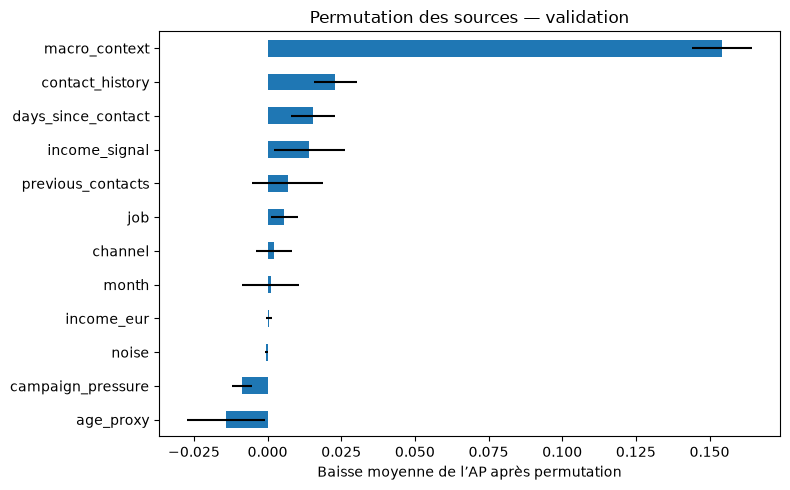

,baisse AP,écart-type
macro_context,0.1541,0.0102
contact_history,0.0230,0.0074
days_since_contact,0.0153,0.0075
income_signal,0.0141,0.0121
previous_contacts,0.0068,0.0120
job,0.0057,0.0045
channel,0.0021,0.0061
month,0.0010,0.0097
income_eur,0.0004,0.0009
noise,-0.0004,0.0004


In [10]:
display(summarize_cv(['Logistique', *feature_models]).style.format(cv_format))
ablation_rows = []
for name in feature_models:
    delta = cv_scores[name]['test_ap'] - cv_scores['Logistique']['test_ap']
    ablation_rows.append({
        'famille': name, 'Δ AP moyen': delta.mean(),
        'écart-type des Δ': delta.std(), 'plis en progrès / 5': int((delta > 0).sum())
    })
display(pd.DataFrame(ablation_rows).round(4))

feature_model = clone(feature_models['Features complètes']).fit(X_train, y_train)
perm = permutation_importance(feature_model, X_valid, y_valid, scoring='average_precision',
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=N_JOBS)
importance = pd.DataFrame({
    'baisse AP': perm.importances_mean, 'écart-type': perm.importances_std
}, index=X_valid.columns).sort_values('baisse AP')
importance['baisse AP'].plot.barh(xerr=importance['écart-type'], figsize=(8, 5),
                                title='Permutation des sources — validation')
plt.xlabel('Baisse moyenne de l’AP après permutation')
plt.tight_layout()
plt.show()
importance.sort_values('baisse AP', ascending=False).round(4)

## 10. Exercices de fin de séance

1. Remplacez `class_weight='balanced'` par un ratio de poids métier et comparez AP, Brier et volume d’alertes.
2. Comparez `sigmoid` et `isotonic`. Quelle méthode choisiriez-vous si vous disposez de seulement 500 exemples de calibration ?
3. Ajoutez une interaction métier justifiée, puis vérifiez son gain par ablation dans une CV.
4. Proposez un target encoding pour `job` : expliquez exactement où le cross-fitting doit être placé.
5. Expliquez pourquoi équilibrer le jeu de test fausserait l’évaluation de la précision, du coût et de la calibration.

Les réponses ci-dessous complètent le protocole, avant toute ouverture du test.

### Exercice 1 — Poids métier 1:5

On propose `{0: 1, 1: 5}` car un faux négatif coûte ici cinq fois plus qu’un faux positif. Contrairement à `balanced`, ce ratio est fixé par le scénario, pas par les effectifs du pli. On compare AP, Brier, rappel et alertes au même seuil 0,5, sans plafond pour isoler l’effet des poids.

Ces poids agissent pendant l’apprentissage ; ils ne garantissent ni des probabilités calibrées ni un coût minimal. Appliquer directement le seuil théorique de 1/6 aux scores pondérés non calibrés compterait les coûts deux fois dans le cas idéal. On sépare donc apprentissage, calibration sur prévalence naturelle et décision finale.

In [11]:
business_model = make_logit(class_weight={0: 1, 1: 5})
models['Poids métier 1:5'] = business_model
evaluate_models({'Poids métier 1:5': business_model})
weight_results = summarize_cv(['Logistique', 'Logistique pondérée', 'Poids métier 1:5'])
display(weight_results.style.format(cv_format))
print(f'Ratio balanced approximatif sur train : {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1')
print('Le ratio balanced exact est recalculé dans chaque pli. Les alertes portent sur 3 000 prédictions OOF.')

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
0,Logistique,0.217,0.046,0.08054,0.000,8
2,Poids métier 1:5,0.193,0.029,0.13544,0.328,387
1,Logistique pondérée,0.183,0.028,0.21663,0.646,1042


Ratio balanced approximatif sur train : 9.83:1
Le ratio balanced exact est recalculé dans chaque pli. Les alertes portent sur 3 000 prédictions OOF.


### Exercice 2 — Sigmoïde ou isotonique ?

On garde la même logistique pondérée. La **CV externe** évalue le pipeline calibré ; à l’intérieur de chaque train externe, la **CV interne** fournit les scores d’apprentissage du calibrateur. Avec `ensemble=False`, celui-ci reçoit toutes les prédictions OOF du train externe (2 400 ici), puis le modèle de base est réentraîné sur ces 2 400 lignes. Aucun label du pli externe évalué ne sert à la calibration.

Avec **500 exemples de calibration**, soit environ 45 positifs à cette prévalence, je privilégierais **`sigmoid`** : deux paramètres et moins de variance. L’isotonique ajuste une fonction monotone par morceaux et peut surapprendre ou créer beaucoup d’ex æquo avec peu de positifs. Ce n’est pas une garantie universelle : on vérifie le Brier sur des données indépendantes. Le choix ci-dessous concerne cette logistique pondérée ; le modèle final sera comparé à nouveau dans sa propre configuration.

In [12]:
calibration_models = {
    'Pondérée + sigmoid': make_calibrated(make_logit(class_weight='balanced'), 'sigmoid'),
    'Pondérée + isotonic': make_calibrated(make_logit(class_weight='balanced'), 'isotonic')
}
evaluate_models(calibration_models)
calibration_results = summarize_cv(['Logistique pondérée', *calibration_models])
display(calibration_results.style.format(cv_format))
best_calibration_demo = calibration_results.sort_values('Brier moyen').iloc[0]
print('Meilleur Brier CV pour cette comparaison :', best_calibration_demo['modèle'])

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
0,Logistique pondérée,0.183,0.028,0.21663,0.646,1042
1,Pondérée + sigmoid,0.183,0.028,0.08142,0.000,3
2,Pondérée + isotonic,0.171,0.024,0.07998,0.000,0


Meilleur Brier CV pour cette comparaison : Pondérée + isotonic


### Exercice 3 — Interaction revenu × historique récent

**Hypothèse métier :** l’association entre revenu et souscription pourrait varier selon l’intensité de l’historique de contact. On ajoute `income_x_contact_rate = log_income × contacts_per_known_day` aux features complètes. L’interaction combine un revenu en euros transformé et un indice de contacts/jour ; ce n’est pas une grandeur physique directement interprétable.

Les deux sources sont disponibles avant l’appel, les conventions de cas limites sont celles de la section 8, et une valeur manquante reste imputée dans le pli. Le produit est créé avant la standardisation. L’ablation ne change **que cette interaction**, sur les mêmes cinq plis et avec la même régularisation. Un gain nul ou négatif constitue une réponse valide : l’intuition ne remplace pas la mesure.

In [13]:
interaction_model = make_feature_model(interaction=True)
models['Features + interaction'] = interaction_model
evaluate_models({'Features + interaction': interaction_model})
display(summarize_cv(['Features complètes', 'Features + interaction']).style.format(cv_format))
interaction_delta = cv_scores['Features + interaction']['test_ap'] - cv_scores['Features complètes']['test_ap']
display(pd.DataFrame({'pli': np.arange(1, 6), 'Δ AP interaction': interaction_delta}).round(4))
print(f'Δ AP moyen : {interaction_delta.mean():+.4f} ; écart-type des Δ : {interaction_delta.std():.4f}')
print(f'Gain positif dans {(interaction_delta > 0).sum()}/5 plis ; à confronter à la dispersion.')

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
0,Features complètes,0.211,0.043,0.08058,0.000,5
1,Features + interaction,0.209,0.042,0.08063,0.000,5


,pli,Δ AP interaction
0,1,-0.0091
1,2,-0.0004
2,3,0.0004
3,4,-0.0003
4,5,0.0003


Δ AP moyen : -0.0018 ; écart-type des Δ : 0.0037
Gain positif dans 2/5 plis ; à confronter à la dispersion.


### Exercice 4 — Target encoding de `job`

On remplace le one-hot de `job` par une moyenne de cible lissée : $TE(c)=(n_c\bar y_c + m\bar y)/(n_c+m)$, avec **$m=10$ fixé avant l’évaluation**. Les autres catégories restent en one-hot. Le `TargetEncoder` de scikit-learn, déjà installé, gère lui-même le cross-fitting. Avec la version 1.9 du dépôt, on passe un `StratifiedKFold` à `cv` pour fixer le mélange et la graine.

**Emplacement exact du cross-fitting :**
1. La CV externe réserve son pli d’évaluation avant tout encodage.
2. `Pipeline.fit` appelle `ColumnTransformer.fit_transform` sur le train externe. La branche `TargetEncoder.fit_transform` le subdivise en cinq plis : chaque ligne d’entraînement est encodée sans son propre label, à partir des quatre autres plis.
3. L’encodeur mémorise aussi une table apprise sur tout le train externe. Elle sert uniquement à `transform` sur le pli externe, la validation ou le futur test. Une catégorie inconnue reçoit la moyenne du train ; une valeur manquante est traitée comme une catégorie.
4. Si l’on calibre ce pipeline, l’encodage reste **à l’intérieur du modèle de base de chaque pli de calibration**, lui-même à l’intérieur de la CV externe.

Un `groupby('job').mean()` calculé une seule fois avant la CV fuit les labels. Même `encoder.fit(X_train, y_train).transform(X_train)` ne remplace pas `fit_transform`, car il n’effectue pas ce cross-fitting. Avec seulement cinq métiers tirés au hasard, on n’attend pas de gain systématique ; le one-hot est une bonne référence.

In [14]:
target_preprocess = ColumnTransformer([
    ('num', clone(preprocess.transformers[0][1]), num_cols),
    ('job_target', TargetEncoder(
        target_type='binary', smooth=10.0,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    ), ['job']),
    ('cat', clone(preprocess.transformers[1][1]), ['channel', 'month'])
])
target_model = Pipeline([
    ('prep', target_preprocess),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])
models['Target encoding job'] = target_model
evaluate_models({'Target encoding job': target_model})
display(summarize_cv(['Logistique', 'Target encoding job']).style.format(cv_format))
target_delta = cv_scores['Target encoding job']['test_ap'] - cv_scores['Logistique']['test_ap']
print(f'Δ AP moyen vs one-hot : {target_delta.mean():+.4f} ; écart-type des Δ : {target_delta.std():.4f}')

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
0,Logistique,0.217,0.046,0.08054,0.000,8
1,Target encoding job,0.216,0.041,0.08039,0.000,7


Δ AP moyen vs one-hot : -0.0014 ; écart-type des Δ : 0.0103


### Exercice 5 — Pourquoi conserver la prévalence du test ?

Équilibrer le test remplace la population visée par une population artificielle. Même si rappel (TPR) et taux de faux positifs (FPR) restent inchangés dans un échantillonnage aléatoire au sein de chaque classe, la précision dépend de la prévalence $\pi$ :

$$\mathrm{Precision}=\frac{\pi\,TPR}{\pi\,TPR+(1-\pi)\,FPR}.$$

Avec 70 % de rappel et 10 % de FPR, elle vaut environ **41 % à 9 % de prévalence**, contre **88 % à 50 %**. L’AP, le volume d’alertes et l’accuracy changent aussi.

Le coût moyen vaut $C_{FP}(1-\pi)FPR + C_{FN}\pi(1-TPR)$ : pour FP = 1 et FN = 5, cela donne **0,226** unité/client à 9 %, contre **0,800** à 50 %. Comparer des coûts totaux après changement d’effectif serait encore moins pertinent.

Enfin, les fréquences positives observées dans les groupes de scores ne correspondent plus aux probabilités prévues pour la population initiale. La courbe de calibration et le Brier sont donc évalués sous une autre distribution. Le test doit conserver la prévalence de déploiement ; le sampling sert uniquement à l’apprentissage. Une étude cas-témoins exigerait des pondérations explicites pour retrouver les métriques de la population cible.

## 11. Figer les choix, puis ouvrir le test une seule fois

**Règle de sélection :** retenir la configuration de base ayant la meilleure AP moyenne en CV sur train. Pour cette configuration, comparer ensuite les probabilités brutes, `sigmoid` et `isotonic` sur les mêmes plis externes, puis retenir le plus petit Brier moyen. Les différences entre candidats restent exploratoires : multiplier les essais rend les scores de sélection optimistes. Le test fournit l’évaluation indépendante de la configuration choisie.

On entraîne le modèle retenu sur les 3 000 lignes du train, puis on choisit le seuil sur les 1 000 lignes de validation avec les coûts et la capacité déjà fixés. **On conserve ce modèle entraîné après le réglage du seuil** : le réentraîner avec la validation changerait les scores auxquels ce seuil s’applique.

La cellule de choix ci-dessous ne consulte pas le test. Après l’évaluation finale, les résultats servent à conclure, pas à relancer une sélection.

In [15]:
ranking_results = summarize_cv(models)
display(ranking_results.style.format(cv_format))
selected_name = ranking_results.iloc[0]['modèle']
selected_estimator = models[selected_name]
probability_candidates = {
    selected_name: selected_estimator,
    f'{selected_name} / sigmoid': make_calibrated(selected_estimator, 'sigmoid'),
    f'{selected_name} / isotonic': make_calibrated(selected_estimator, 'isotonic')
}
# La variante brute a déjà été évaluée ; seules les deux calibrations sont nouvelles.
evaluate_models({name: model for name, model in probability_candidates.items() if name != selected_name})
probability_results = summarize_cv(probability_candidates).sort_values('Brier moyen')
display(probability_results.style.format(cv_format))
final_name = probability_results.iloc[0]['modèle']
final_model = clone(probability_candidates[final_name]).fit(X_train, y_train)
p_valid_final = final_model.predict_proba(X_valid)[:, 1]
final_threshold_table, final_best = choose_threshold(y_valid, p_valid_final, MAX_CALLS)
final_threshold = float(final_best['seuil'])
print('Modèle figé :', final_name)
print(f'Seuil figé : {final_threshold:.6f} ; capacité : {MAX_CALLS} appels par lot de 1 000')
print(f'Coûts figés : FP = {C_FP}, FN = {C_FN}')
display(pd.DataFrame([final_best], index=['Validation — réglage']).round(4))

,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
1,Logistique,0.217,0.046,0.08054,0.000,8
9,Target encoding job,0.216,0.041,0.08039,0.000,7
5,Features contacts,0.214,0.045,0.08067,0.000,9
4,Features revenu,0.213,0.042,0.08046,0.000,5
6,Features complètes,0.211,0.043,0.08058,0.000,5
8,Features + interaction,0.209,0.042,0.08063,0.000,5
7,Poids métier 1:5,0.193,0.029,0.13544,0.328,387
3,Logistique + SMOTE,0.184,0.028,0.21419,0.646,1019
2,Logistique pondérée,0.183,0.028,0.21663,0.646,1042
0,Dummy prior,0.092,0.001,0.08381,0.000,0


,modèle,AP moyenne,AP écart-type,Brier moyen,Rappel à 0.5,Alertes OOF à 0.5
2,Logistique / isotonic,0.193,0.023,0.07963,0.000,0
1,Logistique / sigmoid,0.217,0.046,0.08034,0.000,3
0,Logistique,0.217,0.046,0.08054,0.000,8


Modèle figé : Logistique / isotonic
Seuil figé : 0.254355 ; capacité : 100 appels par lot de 1 000
Coûts figés : FP = 1, FN = 5


,seuil,TN,FP,FN,TP,coût,alertes,précision,rappel
Validation — réglage,0.2544,842.0,66.0,58.0,34.0,356.0,100.0,0.34,0.3696


,modèle,AP test,Brier test
0,Dummy prior (référence),0.0920,0.0835
1,Logistique / isotonic,0.2088,0.0770


,TN,FP,FN,TP,coût,alertes,précision,rappel
Test — règle figée,836,72,64,28,392,100,0.28,0.3043


Coût de la référence « appeler personne » : 460
              precision    recall  f1-score   support

         non       0.93      0.92      0.92       908
         oui       0.28      0.30      0.29        92

    accuracy                           0.86      1000
   macro avg       0.60      0.61      0.61      1000
weighted avg       0.87      0.86      0.87      1000



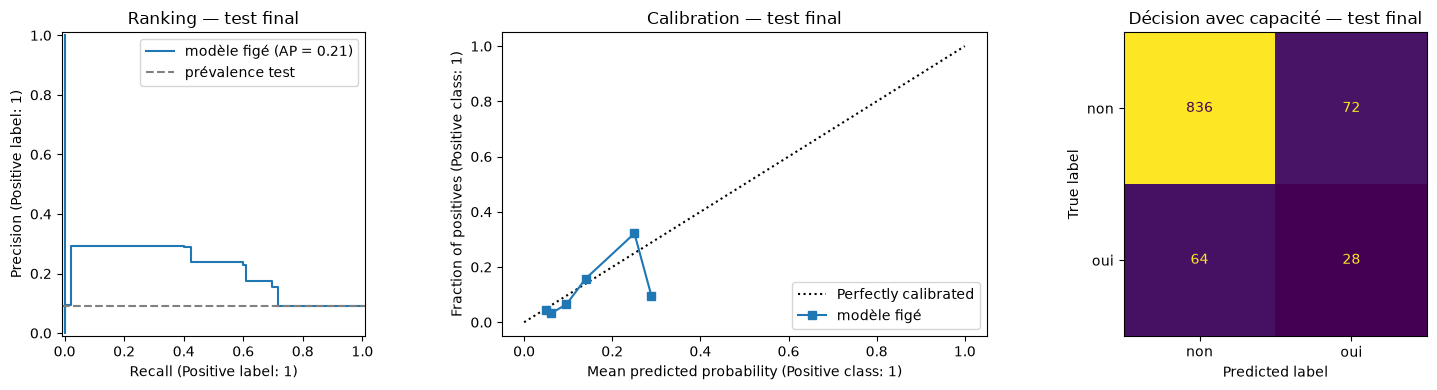

In [16]:
# Ouverture unique du test : aucun fit ni recherche de seuil dans cette cellule.
p_test = final_model.predict_proba(X_test)[:, 1]
pred_test = decide(p_test, final_threshold, MAX_CALLS)
assert np.isfinite(p_test).all() and ((p_test >= 0) & (p_test <= 1)).all()
assert pred_test.sum() <= MAX_CALLS
test_decision = decision_metrics(y_test, pred_test)
prior_test = np.full(len(y_test), y_train.mean())
display(pd.DataFrame([
    {'modèle': 'Dummy prior (référence)',
     'AP test': average_precision_score(y_test, prior_test),
     'Brier test': brier_score_loss(y_test, prior_test)},
    {'modèle': final_name, 'AP test': average_precision_score(y_test, p_test),
     'Brier test': brier_score_loss(y_test, p_test)}
]).round(4))
display(pd.DataFrame([test_decision], index=['Test — règle figée']).round(4))
print(f'Coût de la référence « appeler personne » : {C_FN * int(y_test.sum())}')
print(classification_report(y_test, pred_test, target_names=['non', 'oui'], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[0], name='modèle figé')
axes[0].axhline(y_test.mean(), color='grey', ls='--', label='prévalence test')
axes[0].legend()
CalibrationDisplay.from_predictions(y_test, p_test, n_bins=10, strategy='quantile',
                                    ax=axes[1], name='modèle figé')
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=[0, 1],
                                        display_labels=['non', 'oui'], ax=axes[2], colorbar=False)
axes[0].set_title('Ranking — test final')
axes[1].set_title('Calibration — test final')
axes[2].set_title('Décision avec capacité — test final')
plt.tight_layout()
plt.show()

## Bilan et checklist de livraison

### Conclusions de l’exécution avec la graine 42

- **Déséquilibre :** la logistique non pondérée obtient la meilleure AP moyenne parmi les configurations de base (0,217). La pondération `balanced` augmente le rappel à 0,5 de 0 à environ 0,646, mais fait passer les alertes OOF de 8 à 1 042 et dégrade le Brier. Les poids métier 1:5 donnent un compromis de 387 alertes, sans gain d’AP (0,193). SMOTE n’améliore pas non plus l’AP ici (0,184).
- **Calibration :** sur la logistique pondérée, le Brier passe d’environ 0,217 à 0,081 avec la sigmoïde et 0,080 avec l’isotonique. La sigmoïde conserve l’AP ; les ex æquo isotoniques peuvent la diminuer. La préférence prudente pour une sigmoïde avec seulement 500 exemples ne contredit pas le résultat de cette CV, où le calibrateur dispose de 2 400 scores OOF par train externe.
- **Features :** les trois variantes ont un delta d’AP moyen négatif face à la baseline. L’interaction ajoute un delta de −0,0018 face aux features complètes, positif dans seulement 2/5 plis : on ne la retient pas. Le target encoding donne −0,0014 face au one-hot, avec un écart-type des deltas de 0,0103 ; ce jeu ne justifie pas sa complexité supplémentaire.
- **Choix final :** logistique non pondérée, puis calibration isotonique selon le plus petit Brier en CV. Cette règle accepte une baisse d’AP CV d’environ 0,217 à 0,193 en échange du meilleur Brier mesuré ; les faibles écarts de Brier ne prouvent pas une supériorité universelle. Le seuil de validation est d’environ 0,254355, avec un plafond de 100 appels.
- **Test final :** AP **0,2088**, Brier **0,0770**, **100 appels**, **28 vrais positifs**, **72 faux positifs** et **64 faux négatifs**. La précision vaut 28 % et le rappel 30,4 %. Le coût est **392**, contre **460** si l’on n’appelle personne : gain observé de 68 unités, sans ajustement après lecture du test.

### Protocole vérifié

Le classement, les probabilités et la décision répondent à trois questions différentes. Les tableaux de CV mesurent les effets de la pondération, du sampling et des transformations ; les ablations donnent le gain marginal des familles et de l’interaction. Le test final décrit uniquement le modèle et la règle figés, avec un budget respecté même si la distribution des scores change.

- [x] Split stratifié adapté aux observations synthétiques indépendantes ; pas de groupes ni de vraie chronologie disponibles.
- [x] Sampler appliqué seulement au train de chaque pli, dans une pipeline imbalanced-learn.
- [x] Comparaison à `DummyClassifier` et à une logistique non pondérée.
- [x] Calibration apprise sur scores hors pli ; comparaison par CV externe ou validation séparée.
- [x] Seuil choisi sur validation ; coûts FP = 1, FN = 5 et plafond de 100 appels documentés.
- [x] Features disponibles avant l’appel, formules et cas limites documentés ; `duration_after_call` exclue.
- [x] Ablations appariées en CV et permutation sur validation, sans sélection sur test.
- [x] Test évalué dans une seule cellule, après tous les choix, sans réentraînement ni ajustement ensuite.

Les données sont synthétiques, les coûts illustratifs et le nombre de positifs limité. Une meilleure moyenne sur cinq plis ne démontre ni causalité ni gain universel ; des gains faibles doivent être confirmés sur de nouvelles données représentatives.

### Références

- [scikit-learn — calibration et `ensemble=False`](https://scikit-learn.org/stable/modules/calibration.html).
- [scikit-learn — `TargetEncoder` et cross-fitting de `fit_transform`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html).
- [imbalanced-learn — fuites de données et pipeline de rééchantillonnage](https://imbalanced-learn.org/stable/common_pitfalls.html).
- [imbalanced-learn — données mixtes avec `SMOTENC`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html).